<a href="https://colab.research.google.com/github/AaryadityaSP/Deep-Learning/blob/main/Vanishing_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [58]:
X,y = make_moons(n_samples=250, noise=0.05)

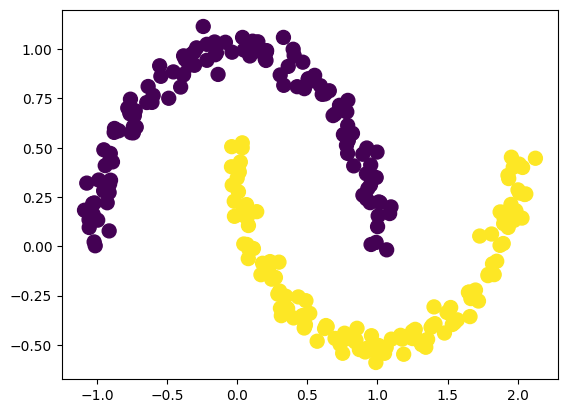

In [59]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [29]:
model=Sequential()

model.add(Dense(10, activation='sigmoid', input_dim=2))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [30]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [31]:
model.get_weights()

[array([[ 0.6714669 ,  0.4696669 , -0.0200597 , -0.5834032 , -0.21732837,
          0.15427601, -0.27435726, -0.1950534 ,  0.6267651 ,  0.24953175],
        [-0.6977043 , -0.27378845, -0.32451487, -0.3186676 ,  0.4110046 ,
         -0.5608555 , -0.4032415 ,  0.6883618 ,  0.5605865 , -0.6191559 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-4.37371254e-01, -6.10474348e-02,  1.44984603e-01,
         -3.75322104e-02,  4.76606131e-01, -7.58206546e-02,
         -3.74635339e-01, -5.27637362e-01,  4.06945348e-01,
         -1.95207030e-01],
        [ 4.61645722e-02,  1.30235016e-01, -2.14849055e-01,
          3.00790191e-01, -1.41651124e-01, -7.31335580e-02,
          3.21239233e-02, -6.51128888e-02, -1.67074800e-02,
         -4.95106757e-01],
        [ 9.39953923e-02, -1.09259874e-01,  9.70548987e-02,
          4.81983542e-01,  7.24286437e-02,  1.14995897e-01,
          1.86194956e-01,  2.54074991e-01,  3.97133827e-02,
         -3.5320243

In [32]:
old_weights=model.get_weights()[0]
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [33]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4900 - loss: 0.6993
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6968 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6945 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6943 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6938 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4300 - loss: 0.6936 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4600 - loss: 0.6931 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6933 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4500 - loss: 0.6934 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6931  
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - los

In [34]:
new_weights=model.get_weights()[0]

In [35]:
model.optimizer.get_config()["learning_rate"]


0.0010000000474974513

In [39]:
gradient=(old_weights-new_weights)/0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [41]:
percent_change

array([[  10.413289,   39.335445, 1885.412   ,   31.558514,  131.178   ,
         196.43054 ,  148.70758 ,  143.83409 ,   25.199667,   24.71704 ],
       [ 188.78123 ,  491.85214 ,  420.27377 ,  424.0731  ,  333.85953 ,
         241.49342 ,  326.24863 ,  198.33931 ,  221.37239 ,  175.13684 ]],
      dtype=float32)